# Practice: question answering with retrieval

In this homework you will build a retrieval-based question answering system, one component at a time.

_Okay, realistically, there's like, two components, but technically it's one component at a time._


![img](https://www.cs.upc.edu/~mlatifi/index_files/qa-logo.jpg)



There are two parts to this type of systems: a retriever and a generator.
- the retriever subsystem searches for similar texts from a given databse, e.g. wikipedia
- the generator uses the texts found by the retriever to generate an answer in natural language

_this seminar is based on original notebook by [Oleg Vasilev](https://github.com/Omrigan/)_



In [1]:
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

### Part 0: the dataset

Before we train anything, let's take a look at the question answering data that we can use. There are several popular datasets, e.g. TriviaQA for trivia questions or GSM8K for math. Today's data is Stanford Question Answering Dataset (SQuAD). Given a paragraph of text and a question, our model's task is to select a snippet that answers the question.

We are not going to solve the full task today. Instead, we'll train a model to __select the sentence containing answer__ among several options.

As usual, you are given an utility module with data reader and some helper functions

In [2]:
%pip install --quiet transformers==4.36.2 accelerate==0.24.0 sentencepiece==0.1.99 optimum==1.13.2 auto-gptq==0.4.2
# ^-- if this fails, remove the specific version and install latest ones: pip install --update transformers accelerate ...
!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/2023/week_extra/retrieval/data.py -O data.py
!wget https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v2.0.json -O squad-v2.0.json 2> log

  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement auto-gptq==0.4.2 (from versions: 0.0.4, 0.0.5, 0.1.0, 0.2.0, 0.2.1, 0.2.2, 0.3.0, 0.3.1, 0.3.2, 0.5.0, 0.5.1, 0.6.0, 0.7.0, 0.7.1)
ERROR: No matching distribution found for auto-gptq==0.4.2
--2026-03-27 21:09:53--  https://raw.githubusercontent.com/yandexdataschool/nlp_course/2023/week_extra/retrieval/data.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3553 (3.5K) [text/plain]
Saving to: ‘data.py’

data.py             100%[===================>]   3.47K  --.-KB/s    in 0s      

2026-03-27 21:09:53 (72.4 MB/s) - ‘data.py

In [3]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
import data
# backup download link: https://www.dropbox.com/s/q4fuihaerqr0itj/squad.tar.gz?dl=1
train, test = data.build_dataset('./squad-v2.0.json')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
pid, question, options, correct_indices, wrong_indices = train.iloc[40]
print('QUESTION', question, '\n')
print('TEXT SENTENCES')
for i, cand in enumerate(options):
    print(['[ ]', '[v]'][i in correct_indices], cand)

QUESTION Where did Beyonce get her name from? 

TEXT SENTENCES
[ ] Beyoncé Giselle Knowles was born in Houston, Texas, to Celestine Ann "Tina" Knowles (née Beyincé), a hairdresser and salon owner, and Mathew Knowles, a Xerox sales manager.
[v] Beyoncé's name is a tribute to her mother's maiden name.
[ ] Beyoncé's younger sister Solange is also a singer and a former member of Destiny's Child.
[ ] Mathew is African-American, while Tina is of Louisiana Creole descent (with African, Native American, French, Cajun, and distant Irish and Spanish ancestry).
[ ] Through her mother, Beyoncé is a descendant of Acadian leader Joseph Broussard.
[ ] She was raised in a Methodist household.


### Pre-trained BERT
_(but you guessed it)_

We've already solved quite a few tasks from scratch, training our own embeddings and convolutional/recurrent layers. However, one can often achieve higher quality by using pre-trained models. We will default to the good ol' [BERT](https://arxiv.org/abs/1810.04805), though, you are free to use any [other model](https://huggingface.co/models) as you see fit.


In [8]:
from transformers import AutoTokenizer, AutoModel, pipeline

tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-Embedding-0.6B', padding_side='left')
model = AutoModel.from_pretrained('Qwen/Qwen3-Embedding-0.6B')
device = torch.device('cuda')

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [10]:
dummy_lines = [
    "How old are you?",                                                 # 0
    "In what mythology do two canines watch over the Chinvat Bridge?",  # 1
    "I'm sorry, okay, I'm not perfect, but I'm trying.",                # 2
    "What is your age?",                                                # 3
    "Beware, for I am fearless, and therefore powerful.",               # 4
]

def last_token_pool(last_hidden_states: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return last_hidden_states[:, -1]
    else:
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = last_hidden_states.shape[0]
        return last_hidden_states[torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths]
    
model.to(device)
with torch.no_grad():
    batch_dict = tokenizer(dummy_lines, padding=True, truncation=True, max_length=8192, return_tensors="pt")
    batch_dict.to(model.device)
    outputs = model(**batch_dict)
    embeddings = last_token_pool(outputs.last_hidden_state, batch_dict['attention_mask'])
    embeddings = F.normalize(embeddings, p=2, dim=1)

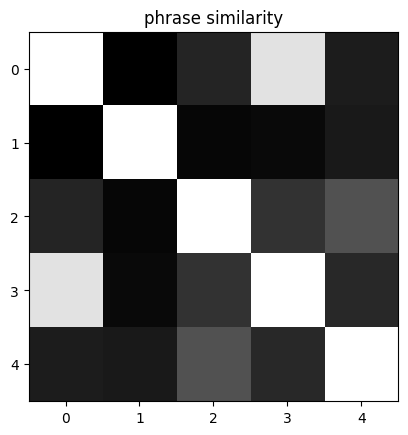

In [11]:
plt.title('phrase similarity')
plt.imshow((embeddings @ embeddings.t()).cpu().float().numpy(), interpolation='none', cmap='gray')

As you can see, __the strongest similarity is between lines 0 and 3__. Indeed they correspond to "How old are you?" and "What is your age?"

### Retriever Model (2 points)

Our goal for today is to build a model that measures similarity between question and answer. In particular, it maps both question and answer into fixed-size vectors such that:

Our model is a pair of $V_q(q)$ and $V_a(a)$ - networks that turn phrases into vectors.

__Objective:__ Question vector $V_q(q)$ should be __closer__ to correct answer vectors $V_a(a^+)$ than to incorrect ones $V_a(a^-)$ .

Both vectorizers can be anything you wish. For starters, let's use a couple of dense layers on top of the pre-trained encoder.




In [12]:
class Vectorizer(nn.Module):
    def __init__(self, model=model, tokenizer=tokenizer):
        """ A small feedforward network on top of pre-trained encoder. 2-3 layers should be enough """
        super().__init__()
        self.model = model
        self.tokenizer = tokenizer
        # define a few layers to be applied on top of pre-trained BERT
        # note: please make sure your final layer comes with _linear_ activation
        # self.mlp = nn.Linear(1024, hid_size)


    def forward(self, input_phrases):
        """
        Apply vectorizer. Use dropout and any other hacks at will.
        :param input_phrases: a list of strings, [batch_size]
        :returns: predicted phrase vectors, [batch_size, output_size]

        Note: you may want to use dropouts.
        if self.training:
          <something>

        Note 2: you may also want to use with torch.no_grad to avoid training BERT for your first attempts

        """

        with torch.no_grad():
            batch_dict = self.tokenizer(input_phrases, padding=True, truncation=True, max_length=2048, return_tensors="pt")
            batch_dict.to(self.model.device)
            outputs = self.model(**batch_dict)
            embeddings = last_token_pool(outputs.last_hidden_state, batch_dict['attention_mask'])
            # embeddings = F.normalize(embeddings, p=2, dim=1)
        
        # phrase_vectors = self.mlp(embeddings.float())

        return F.normalize(embeddings, p=2, dim=1)

In [13]:
question_vectorizer = Vectorizer(model=model, tokenizer=tokenizer)
answer_vectorizer = Vectorizer(model=model, tokenizer=tokenizer)

question_vectorizer.to(device)
answer_vectorizer.to(device);

In [14]:
question_vectorizer.train(False)
out1 = question_vectorizer(dummy_lines)
out2 = question_vectorizer(dummy_lines)
# assert tuple(out1.shape) == (5, question_vectorizer.hid_size)
assert torch.allclose(out1, out2, atol=1e-5, rtol=0), "Make sure your model disables dropout if training == False"
print("Well done!")

Well done!


### Retriever training: minibatches

Our model learns on triples $(q, a^+, a^-)$:
* q - <b>q</b>uestion
* (a+) - correct <b>a</b>nswer
* (a-) - wrong <b>a</b>nswer

Below you will find a generator that samples such triples from data.

In [15]:
import random

def iterate_minibatches(data, batch_size, shuffle=True, cycle=False):
    """
    Generates minibatches of triples: {questions, correct answers, wrong answers}
    If there are several wrong (or correct) answers, picks one at random.
    """
    indices = np.arange(len(data))
    while True:
        if shuffle:
            indices = np.random.permutation(indices)
        for batch_start in range(0, len(indices), batch_size):
            batch_indices = indices[batch_start: batch_start + batch_size]
            batch = data.iloc[batch_indices]
            questions = batch['question'].values
            correct_answers = np.array([
                row['options'][random.choice(row['correct_indices'])]
                for i, row in batch.iterrows()
            ])
            wrong_answers = np.array([
                row['options'][random.choice(row['wrong_indices'])]
                for i, row in batch.iterrows()
            ])

            yield {
                'questions' : questions,
                'correct_answers': correct_answers,
                'wrong_answers': wrong_answers,
            }
        if not cycle:
            break

In [16]:
dummy_batch = next(iterate_minibatches(train.sample(3), 3))
print(dummy_batch)

{'questions': array(['What ultimately convinced Hitler that Raeder was right?',
       'What type of deviations are there from the single phoneme to each grapheme general principle?',
       'When did Barbados get independence?'], dtype=object), 'correct_answers': array(['Hitler had been convinced by Raeder that this was the right course of action due to the high success rates of the U-Boat force during this period of the war.',
       "Although the Estonian orthography is generally guided by phonemic principles, with each grapheme corresponding to one phoneme, there are some historical and morphological deviations from this: for example preservation of the morpheme in declension of the word (writing b, g, d in places where p, k, t is pronounced) and in the use of 'i' and 'j'.",
       'Barbados achieved independence in 1966 and the remainder of the eastern Caribbean islands in the 1970s and 1980s, but Anguilla and the Turks and Caicos Islands opted to revert to British rule after they

### Retriever training: loss function (2 points)
We want our vectorizers to put correct answers closer to question vectors and incorrect answers farther away from them. One way to express this is to use is Pairwise Hinge Loss _(aka Triplet Loss)_.

$$ L = \frac 1N \underset {q, a^+, a^-} \sum max(0, \space \delta - sim[V_q(q), V_a(a^+)] + sim[V_q(q), V_a(a^-)] )$$

, where
* sim[a, b] is some similarity function: dot product, cosine or negative distance
* δ - loss hyperparameter, e.g. δ=1.0. If sim[a, b] is linear in b, all δ > 0 are equivalent.


This reads as __Correct answers must be closer than the wrong ones by at least δ.__

![img](https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/margin.png)
<center>_image: question vector is green, correct answers are blue, incorrect answers are red_</center>


Note: in effect, we train a Deep Semantic Similarity Model [DSSM](https://www.microsoft.com/en-us/research/project/dssm/).

In [17]:
def similarity(a, b):
    return (a * b).sum(dim=1)

def compute_loss(question_vectors, correct_answer_vectors, wrong_answer_vectors, delta=1.0):
    """
    Compute the triplet loss as per formula above.
    Use similarity function above for  sim[a, b]
    :param question_vectors: float32[batch_size, vector_size]
    :param correct_answer_vectors: float32[batch_size, vector_size]
    :param wrong_answer_vectors: float32[batch_size, vector_size]
    :returns: loss for every row in batch, float32[batch_size]
    Hint: you can compute max(0, *) using torch.relu :)
    """
    return torch.relu(delta - similarity(question_vectors, correct_answer_vectors) + similarity(question_vectors, wrong_answer_vectors))

In [18]:
dummy_v1 = torch.tensor([[0.1, 0.2, -1], [-1.2, 0.6, 1.0]], dtype=torch.float32)
dummy_v2 = torch.tensor([[0.9, 2.1, -6.6], [0.1, 0.8, -2.2]], dtype=torch.float32)
dummy_v3 = torch.tensor([[-4.1, 0.1, 1.2], [0.3, -1, -2]], dtype=torch.float32)

assert np.allclose(similarity(dummy_v1, dummy_v2).data.numpy(), [7.11, -1.84])
assert np.allclose(compute_loss(dummy_v1, dummy_v2, dummy_v3, delta=5.0).data.numpy(), [0.0, 3.88])

Once loss is working, let's train our model by our usual means.

In [19]:
# we also compute recall: the rate at which a^+ is closer to q than a^-
def get_recall(questions, correct_answers, wrong_answers):
    v_questions = question_vectorizer(questions.tolist())
    v_correct = answer_vectorizer(correct_answers.tolist())
    v_incorrect = answer_vectorizer(wrong_answers.tolist())
    
    correct_is_closer = similarity(v_questions, v_correct) > similarity(v_questions, v_incorrect)

    recall = torch.mean(correct_is_closer.to(torch.float32)).item()
    return recall

In [20]:
get_recall(**dummy_batch)

1.0

### Training loop (1 point)

Just as we always do, we can now train DSSM on minibatches and periodically measure recall on validation data.


__Note 1:__ triplet loss training may be very sensitive to the choice of batch size. Small batch size may decrease model quality because there are less negative to consider.

__Note 2:__ here we use the same dataset as __"test set"__ and __"validation (dev) set"__.

In any serious scientific experiment, those must be two separate sets. Validation is for hyperparameter tuning and test is for final eval only.


In [21]:
import pandas as pd
from IPython.display import clear_output
from tqdm import tqdm

# Initialize model, optimizers, anything else you want
question_vectorizer = Vectorizer(model=model, tokenizer=tokenizer)
answer_vectorizer = Vectorizer(model=model, tokenizer=tokenizer)
question_vectorizer.to(device)
answer_vectorizer.to(device)
# answer_vectorizer.train()
# question_vectorizer.train()
answer_vectorizer.eval()
question_vectorizer.eval()

# optimizer_ans = torch.optim.AdamW(answer_vectorizer.parameters(), lr=0.001)
# optimizer_qst = torch.optim.AdamW(question_vectorizer.parameters(), lr=0.001)

ewma = lambda x, span: pd.DataFrame({'x': x})['x'].ewm(span=span).mean().values
dev_batches = iterate_minibatches(test, batch_size=128, cycle=True)
loss_history = []
dev_recall_history = []

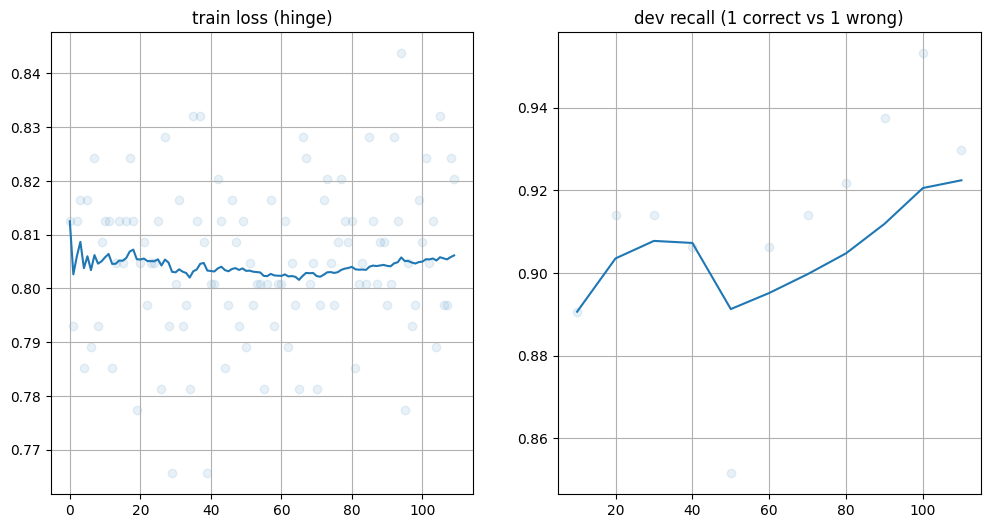

In [20]:
# infinite training loop. Stop it manually or implement early stopping
"""НЕ БУДЕМ НИЧЕГО ОБУЧАТЬ, ЭМБЕДДИНГ МОДЕЛЬ И ТАК ДАЕТ ХОРОШОЕ КАЧЕСТВО, ПРОГОНИМ ДЛЯ ПОСТРОЕНИЯ ГРАФИКОВ"""
for batch in iterate_minibatches(train, batch_size=128, cycle=True):
    # optimizer_ans.zero_grad()
    # optimizer_qst.zero_grad()

    with torch.no_grad():
        question_vectors = question_vectorizer(batch['questions'].tolist())
        correct_ans_vectors = answer_vectorizer(batch['correct_answers'].tolist())
        wrong_ans_vectors = answer_vectorizer(batch['wrong_answers'].tolist())

        loss_t = compute_loss(question_vectors, correct_ans_vectors, wrong_ans_vectors).mean()
    # loss_t.backward()
    
    # optimizer_qst.step()
    # optimizer_ans.step()

    loss_history.append(loss_t.item())

    if len(loss_history) % 10 == 0:
        # measure dev recall = P(correct_is_closer_than_wrong | q, a+, a-)
        dev_batch = next(dev_batches)

        # answer_vectorizer.eval()
        # question_vectorizer.eval()

        with torch.no_grad():
            recall_t = get_recall(**dev_batch)

        dev_recall_history.append(recall_t)

        # answer_vectorizer.train()
        # question_vectorizer.train()

    if len(loss_history) % 10 == 0:
        clear_output(True)
        plt.figure(figsize=[12, 6])
        plt.subplot(1, 2, 1), plt.title('train loss (hinge)'), plt.grid()
        plt.scatter(np.arange(len(loss_history)), loss_history, alpha=0.1)
        plt.plot(ewma(loss_history, span=100))
        plt.subplot(1, 2, 2), plt.title('dev recall (1 correct vs 1 wrong)'), plt.grid()
        dev_time = np.arange(1, len(dev_recall_history) + 1) * 10
        plt.scatter(dev_time, dev_recall_history, alpha=0.1)
        plt.plot(dev_time, ewma(dev_recall_history, span=10))
        plt.show()

    if len(dev_recall_history) > 10:
        if np.mean(dev_recall_history[-10:]) > 0.86:
            break


In [21]:
print("Mean recall:", np.mean(dev_recall_history[-10:]))
assert np.mean(dev_recall_history[-10:]) > 0.85, "Please train for at least 85% recall on test set. "\
                                                  "You may need to change vectorizer model for that."
print("Well done!")

Mean recall: 0.91484375
Well done!


# Retriever evaluation (2 point)

Let's see how well does our model perform on actual question answering.

Given a question and a set of possible answers, pick answer with highest similarity to estimate accuracy.

In [ ]:
# optional: any additional preparations, e.g. build index
# <...>
answer_cache = {}
question_cache = {}

In [55]:
def get_answer_vector_cached(answer_text):
    if answer_text not in answer_cache:
        with torch.no_grad():
            vec = answer_vectorizer(answer_text)[0]
        answer_cache[answer_text] = vec
    return answer_cache[answer_text]

def get_question_vector_cached(question_text):
    if question_text not in question_cache:
        with torch.no_grad():
            vec = question_vectorizer(question_text)[0]
        question_cache[question_text] = vec
    return question_cache[question_text]

def select_best_answer(question, possible_answers):
    """
    Predicts which answer best fits the question
    :param question: a single string containing a question
    :param possible_answers: a list of strings containing possible answers
    :returns: integer - the index of best answer in possible_answer
    """
    with torch.no_grad():
        question_vector = get_question_vector_cached(question)
        answer_vectors = torch.stack([get_answer_vector_cached(ans) for ans in possible_answers], dim=0)
        scores = torch.matmul(answer_vectors, question_vector)
        return scores.argmax().item()


In [56]:
predicted_answers = [
    select_best_answer(question, possible_answers)
    for i, (question, possible_answers) in tqdm(test[['question', 'options']].iterrows(), total=len(test))
]

accuracy = np.mean([
    answer in correct_ix
    for answer, correct_ix in zip(predicted_answers, test['correct_indices'].values)
])
print("Accuracy: %0.5f" % accuracy)
assert accuracy > 0.65, "we need more accuracy!"
print("Great job!")

100%|██████████| 26970/26970 [37:07<00:00, 12.11it/s] 

Accuracy: 0.79355
Great job!


In [58]:
def draw_results(question, possible_answers, predicted_index, correct_indices):
    print("Q:", question, end='\n\n')
    for i, answer in enumerate(possible_answers):
        print("#%i: %s %s" % (i, '[*]' if i == predicted_index else '[ ]', answer))

    print("\nVerdict:", "CORRECT" if predicted_index in correct_indices else "INCORRECT",
          "(ref: %s)" % correct_indices, end='\n' * 3)

In [59]:
for i in [1, 100, 1000, 2000, 3000, 4000, 5000]:
    draw_results(test.iloc[i].question, test.iloc[i].options,
                 predicted_answers[i], test.iloc[i].correct_indices)

Q: Which three countries did Beyonce's song "Work It Out" achieve top ten status?

#0: [ ] In July 2002, Beyoncé continued her acting career playing Foxxy Cleopatra alongside Mike Myers in the comedy film, Austin Powers in Goldmember, which spent its first weekend atop the US box office and grossed $73 million.
#1: [*] Beyoncé released "Work It Out" as the lead single from its soundtrack album which entered the top ten in the UK, Norway, and Belgium.
#2: [ ] In 2003, Beyoncé starred opposite Cuba Gooding, Jr., in the musical comedy The Fighting Temptations as Lilly, a single mother whom Gooding's character falls in love with.
#3: [ ] The film received mixed reviews from critics but grossed $30 million in the U.S. Beyoncé released "Fighting Temptation" as the lead single from the film's soundtrack album, with Missy Elliott, MC Lyte, and Free which was also used to promote the film.
#4: [ ] Another of Beyoncé's contributions to the soundtrack, "Summertime", fared better on the US charts.

In [64]:
question = "What is my name?" # your question here!
possible_answers = [
    'мое имя Андрей',
    'мое имя долбоеб', # можно и на русском
    'темно здесь',
    'завтра'
]
predicted_answer = select_best_answer(question, possible_answers)

draw_results(question, possible_answers,
             predicted_answer, [0])

Q: What is my name?

#0: [*] мое имя Андрей
#1: [ ] мое имя долбоеб
#2: [ ] темно здесь
#3: [ ] завтра

Verdict: CORRECT (ref: [0])




### Part 2: to prompt a generator (3 points)

You have built a model that can select the most relevant sentence from a text document. However, this is still not the same as question answering - at least not how humans understand it. The full question answering system shoud answer your question in a dialogue - and perhap even let you ask follow-up questions.

In [66]:
# note: you may want to save pre-trained retriever and restart to free memory
import torch
import transformers

# model_name = 'TheBloke/Mistral-7B-Instruct-v0.2-GPTQ'  # feel free to choose any other model
model_name = 'Qwen/Qwen2-0.5B-Instruct'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name, device_map=device)
tokenizer.pad_token_id = tokenizer.eos_token_id
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map='auto',
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [67]:
pid, question, options, correct_indices, wrong_indices = train.iloc[10]
print('QUESTION', question, '\n')
print('TEXT SENTENCES')
for i, cand in enumerate(options):
    print(['[ ]', '[v]'][i in correct_indices], cand)

QUESTION What was the first album Beyoncé released as a solo artist? 

TEXT SENTENCES
[ ] Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress.
[ ] Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead singer of R&B girl-group Destiny's Child.
[ ] Managed by her father, Mathew Knowles, the group became one of the world's best-selling girl groups of all time.
[v] Their hiatus saw the release of Beyoncé's debut album, Dangerously in Love (2003), which established her as a solo artist worldwide, earned five Grammy Awards and featured the Billboard Hot 100 number-one singles "Crazy in Love" and "Baby Boy".


In [85]:
def answer_question(question, possible_answers, max_new_tokens=256):
    best_idx = select_best_answer(question, possible_answers)
    best_info = possible_answers[best_idx]

    question_and_info = f"""
Question: {question}

Information: {best_info}
""".strip()

    messages = [
        {
            "role": "system",
            "content": (
                "You answer questions using only the provided information. "
                "Reply briefly, naturally, and do not add facts that are not in the information."
            )
        },
        {
            "role": "user",
            "content": question_and_info
        }
    ]

    input_ids = tokenizer.apply_chat_template(messages, return_tensors='pt', add_generation_prompt=True).to(device)

    with torch.no_grad():
        output_tokens = model.generate(input_ids['input_ids'], attention_mask=input_ids['attention_mask'], max_new_tokens=max_new_tokens, do_sample=True, temperature=0.7, top_p=0.9, pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id)
    answer = tokenizer.decode(output_tokens[0, input_ids['input_ids'].shape[1]:], skip_special_tokens=True).strip()

    return answer, best_info, best_idx

In [88]:
pid, question, options, correct_indices, wrong_indices = train.iloc[1000]

answer, retrieved_info, retrieved_idx = answer_question(question, options)

print("Question:", question)
print("Retrieved sentence:", retrieved_info)
print("Predicted index:", retrieved_idx)
print("Generated answer:", answer)

Question: What did one of the treaties between the Tang and Tibet help fix?
Retrieved sentence: The Yarlung rulers of Tibet also signed various peace treaties with the Tang, culminating in a treaty in 821 that fixed the borders between Tibet and China.
Predicted index: 2
Generated answer: The treaty fixed the borders between Tibet and China.


### Optional tasks for bonus points

There are many ways to improve our question answering model. Here's a bunch of things you can do to increase your understanding and get bonus points.

### 1.  Hard Negatives (2+ pts)

Not all wrong answers are equally wrong. As the training progresses, _most negative examples $a^-$ will be to easy._ So easy in fact, that loss function and gradients on such negatives is exactly __0.0__. To improve training efficiency, one can __mine hard negative samples__.

Given a list of answers,
* __Hard negative__ is the wrong answer with highest similarity with question,

$$a^-_{hard} = \underset {a^-} {argmax} \space sim[V_q(q), V_a(a^-)]$$

* __Semi-hard negative__ is the one with highest similarity _among wrong answers that are farther than positive one. This option is more useful if some wrong answers may actually be mislabelled correct answers.

* One can also __sample__ negatives proportionally to $$P(a^-_i) \sim e ^ {sim[V_q(q), V_a(a^-_i)]}$$


The task is to implement at least __hard negative__ sampling and apply it for model training.


### 2. Better prompting (2+ pts)

In the previous example, we manually engineer a prompt for an LLM to solve produce an answer. However, by this point you know multiple ways to make LLM do your bidding. In this assignment, you should try at least some of them:
- try few-shot learning with several handcrafted examples (or hand-picked model inputs)
- compare several instruct and/or non-instruct models; for non-instruct models
  - please not that you should not use apply_chat_template for non-instruct models
- provide some means of quality evaluation to compare your approach against the default one

At the minimum, several (10-20) side-by-side examples would do the trick. However, we'd appreciate creative means of evaluation here (crowdsourcing, asking another LM, anything exotic as long as you can explain it).

### 3. Search engine (3+ pts)

Our basic model only selects answers from 2-5 available sentences in paragraph. You can extend it to search over __the whole dataset__. All sentences in all other paragraphs are viable answers.

The goal is to train such a model and use it to __quickly find top-10 answers from the whole set__.

* You can ask such model a question of your own making - to see which answers it can find among the entire training dataset or even the entire wikipedia.
* Searching for top-K neighbors is easier if you use specialized methods: [KD-Tree](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html) or [HNSW](https://github.com/nmslib/hnswlib).
* This task is much easier to train if you use hard or semi-hard negatives. You can even find hard negatives for one question from correct answers to other questions in batch - do so in-graph for maximum efficiency. See [1.] for more details.
